In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

nltk.download('stopwords')
from nltk.corpus import stopwords

print("Libraries loaded successfully!")

Libraries loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
train_df = pd.read_csv("train_data.csv",engine="python",on_bad_lines="skip")
test_df = pd.read_csv("test_data.csv",engine="python",on_bad_lines="skip")
print("Full training dataset:", train_df.shape)
print("Test dataset:", test_df.shape)

# Use 50,000 tweets for faster training
train_df = train_df.sample(n=50000,random_state=42).reset_index(drop=True)
print("\nTraining subset:", train_df.shape)

# Check sentiment distribution
print("\nSentiment distribution:")
print(train_df["sentiment"].value_counts())
display(train_df.head(10))

Full training dataset: (1873098, 2)
Test dataset: (359, 2)

Training subset: (50000, 2)

Sentiment distribution:
sentiment
0.0    29962
1.0    20038
Name: count, dtype: int64


,sentence,sentiment
0,rawr today is supposed to be family day my par...,0.0
1,now i got a bunch of assignments to finish,0.0
2,its in the morning and i m up drinking hot cho...,1.0
3,you didnt have fun with me,0.0
4,running low on things to do in the craft room ...,0.0
5,wants hair muskkkk rambut rontok bgt,0.0
6,i have to admit i m a little bit jealous and i...,0.0
7,monday night worship party starts tonight at c...,1.0
8,nite dude sorry i missed you online talk to yo...,0.0
9,i missed that vid did u send it tony been work...,1.0


In [11]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

def clean_tweet(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
train_df["clean_text"] = train_df["sentence"].apply(clean_tweet)
display(train_df[["sentence", "clean_text", "sentiment"]].head(10))

,sentence,clean_text,sentiment
0,rawr today is supposed to be family day my par...,rawr today supposed family day parents wanna g...,0.0
1,now i got a bunch of assignments to finish,got bunch assignments finish,0.0
2,its in the morning and i m up drinking hot cho...,morning drinking hot chocolate random craving ...,1.0
3,you didnt have fun with me,didnt fun,0.0
4,running low on things to do in the craft room ...,running low things craft room good,0.0
5,wants hair muskkkk rambut rontok bgt,wants hair muskkkk rambut rontok bgt,0.0
6,i have to admit i m a little bit jealous and i...,admit little bit jealous wanna feel dissapoined,0.0
7,monday night worship party starts tonight at c...,monday night worship party starts tonight come,1.0
8,nite dude sorry i missed you online talk to yo...,nite dude sorry missed online talk tomorrow ho...,0.0
9,i missed that vid did u send it tony been work...,missed vid u send tony working night shift rad...,1.0


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1, 2),min_df=2,max_df=0.95)
X = tfidf.fit_transform(train_df["clean_text"])
y = train_df["sentiment"]

print("TF-IDF matrix shape:", X.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF matrix shape: (50000, 10000)
Number of features: 10000


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 40000
Testing samples: 10000


In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,random_state=42)
print("Training model...")
model.fit(X_train, y_train)
print("Model training completed!")

Training model...
Model training completed!


In [15]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_test,y_pred,target_names=["Negative", "Positive"]))

========== MODEL PERFORMANCE ==========
Accuracy  : 0.7577
Precision : 0.7304
Recall    : 0.6267
F1 Score  : 0.6746

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    Negative       0.77      0.85      0.81      5992
    Positive       0.73      0.63      0.67      4008

    accuracy                           0.76     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.76      0.76      0.75     10000



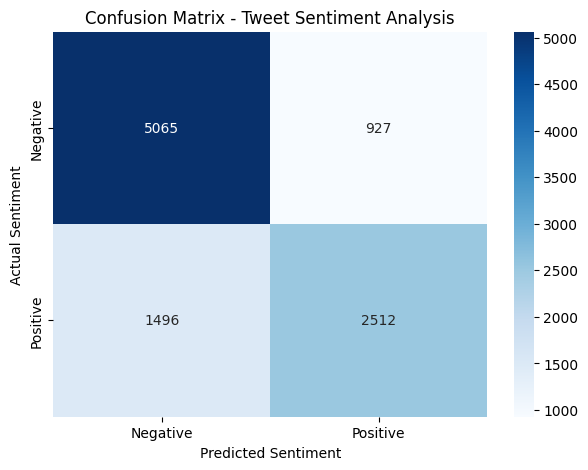

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Negative", "Positive"],yticklabels=["Negative", "Positive"])

plt.title("Confusion Matrix - Tweet Sentiment Analysis")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [17]:
def predict_sentiment(tweet):
    # Clean the tweet
    cleaned = clean_tweet(tweet)

    # Convert to TF-IDF
    vector = tfidf.transform([cleaned])

    # Predict
    prediction = model.predict(vector)[0]

    # Get probability
    probability = model.predict_proba(vector)[0]

    if prediction == 1:
        sentiment = "Positive"
        confidence = probability[1]
    else:
        sentiment = "Negative"
        confidence = probability[0]

    print("Tweet:", tweet)
    print("Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2%}")

In [18]:
predict_sentiment("I absolutely love this movie! It was amazing!")

Tweet: I absolutely love this movie! It was amazing!
Sentiment: Positive
Confidence: 88.05%


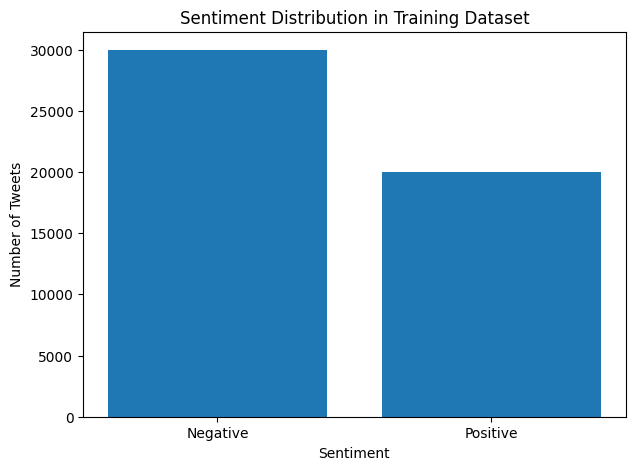

In [19]:
plt.figure(figsize=(7, 5))
sentiment_counts = train_df["sentiment"].value_counts().sort_index()
plt.bar(["Negative", "Positive"],sentiment_counts.values)

plt.title("Sentiment Distribution in Training Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [20]:
test_tweets = [
    "I absolutely love this movie, it was fantastic!",
    "This is the worst day ever.",
    "I am very happy with my new phone.",
    "The service was terrible and disappointing.",
    "Had a great time with my friends today!",
    "I don't like this product at all."
]

for tweet in test_tweets:
    predict_sentiment(tweet)
    print("-" * 60)

Tweet: I absolutely love this movie, it was fantastic!
Sentiment: Positive
Confidence: 87.00%
------------------------------------------------------------
Tweet: This is the worst day ever.
Sentiment: Negative
Confidence: 71.33%
------------------------------------------------------------
Tweet: I am very happy with my new phone.
Sentiment: Positive
Confidence: 75.29%
------------------------------------------------------------
Tweet: The service was terrible and disappointing.
Sentiment: Negative
Confidence: 92.84%
------------------------------------------------------------
Tweet: Had a great time with my friends today!
Sentiment: Positive
Confidence: 71.70%
------------------------------------------------------------
Tweet: I don't like this product at all.
Sentiment: Negative
Confidence: 76.16%
------------------------------------------------------------


In [21]:
while True:
    tweet = input("\nEnter a tweet (or type 'exit' to stop): ")
    if tweet.lower() == "exit":
        print("Sentiment analysis stopped.")
        break

    predict_sentiment(tweet)


Enter a tweet (or type 'exit' to stop): I don't like this product at all.
Tweet: I don't like this product at all.
Sentiment: Negative
Confidence: 76.16%

Enter a tweet (or type 'exit' to stop): exit
Sentiment analysis stopped.
